In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import deque
import gymnasium as gym

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

env = gym.make('CartPole-v1')

state, info = env.reset()
print(f"\nEnvironment info:")
print(f"State space : {env.observation_space}")
print(f"Action space: {env.action_space}")
print(f"State shape : {state.shape}")
print(f"Sample state: {state}")
print(f"Actions     : 0=push left, 1=push right")

state, info  = env.reset()
total_reward = 0
steps        = 0

while True:
    action       = env.action_space.sample()  
    state, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    steps        += 1
    done = terminated or truncated
    if done:
        break

print(f"\nRandom agent episode:")
print(f"Steps survived: {steps}")
print(f"Total reward  : {total_reward}")
print(f"(Random agent typically survives 8-20 steps)")

Device: cuda

Environment info:
State space : Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)
State shape : (4,)
Sample state: [ 0.04310836 -0.00822679  0.0221123   0.0348524 ]
Actions     : 0=push left, 1=push right

Random agent episode:
Steps survived: 61
Total reward  : 61.0
(Random agent typically survives 8-20 steps)


In [ ]:
class DQN(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(DQN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)  
        )
    
    def forward(self, x):
        return self.network(x)


class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)  
    
    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))
    
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (np.array(states), np.array(actions), np.array(rewards),
                np.array(next_states), np.array(dones))
    
    def __len__(self):
        return len(self.buffer)


STATE_DIM  = env.observation_space.shape[0]  
ACTION_DIM = env.action_space.n        

policy_net = DQN(STATE_DIM, ACTION_DIM).to(device) 
target_net = DQN(STATE_DIM, ACTION_DIM).to(device)  
target_net.load_state_dict(policy_net.state_dict())  
target_net.eval()  

replay_buffer = ReplayBuffer(capacity=10000)

print(f"State dim   : {STATE_DIM}")
print(f"Action dim  : {ACTION_DIM}")
print(f"Policy net  : {sum(p.numel() for p in policy_net.parameters()):,} params")
print(f"Buffer size : 10,000 experiences")

State dim   : 4
Action dim  : 2
Policy net  : 17,410 params
Buffer size : 10,000 experiences


In [ ]:
BATCH_SIZE    = 64
GAMMA         = 0.99      
LR            = 1e-3
EPSILON_START = 1.0  
EPSILON_END   = 0.01      
EPSILON_DECAY = 0.995    
TARGET_UPDATE = 10        
N_EPISODES    = 500

optimizer = optim.Adam(policy_net.parameters(), lr=LR)
criterion = nn.MSELoss()

epsilon      = EPSILON_START
episode_rewards = []
avg_rewards     = []

def select_action(state, epsilon):
    if random.random() < epsilon:
        return env.action_space.sample()  
    else:
        with torch.no_grad():
            state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
            q_values     = policy_net(state_tensor)
            return q_values.argmax().item()  


def train_step():
    if len(replay_buffer) < BATCH_SIZE:
        return  
    
    states, actions, rewards, next_states, dones = replay_buffer.sample(BATCH_SIZE)
    
    states      = torch.FloatTensor(states).to(device)
    actions     = torch.LongTensor(actions).to(device)
    rewards     = torch.FloatTensor(rewards).to(device)
    next_states = torch.FloatTensor(next_states).to(device)
    dones       = torch.FloatTensor(dones).to(device)
    
    current_q = policy_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)
    
    with torch.no_grad():
        next_q  = target_net(next_states).max(1)[0]
        target_q = rewards + GAMMA * next_q * (1 - dones)
    
    loss = criterion(current_q, target_q)
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(policy_net.parameters(), 1.0)
    optimizer.step()


print("Training DQN on CartPole...")
print("="*55)

for episode in range(N_EPISODES):
    state, info  = env.reset()
    total_reward = 0
    
    while True:
        action = select_action(state, epsilon)
        
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        
        replay_buffer.push(state, action, reward, next_state, done)
        
        train_step()
        
        state         = next_state
        total_reward += reward
        
        if done:
            break
    
    epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)
    
    if episode % TARGET_UPDATE == 0:
        target_net.load_state_dict(policy_net.state_dict())
    
    episode_rewards.append(total_reward)
    avg_reward = np.mean(episode_rewards[-50:]) 
    avg_rewards.append(avg_reward)
    
    if (episode + 1) % 50 == 0:
        print(f"Episode {episode+1:4d}/{N_EPISODES} | "
              f"Avg Reward (last 50): {avg_reward:.1f} | "
              f"Epsilon: {epsilon:.3f}")
    
    if avg_reward >= 475:
        print(f"\nSolved at episode {episode+1}! Avg reward: {avg_reward:.1f}")
        break

print("\nTraining complete!")

Training DQN on CartPole...
Episode   50/500 | Avg Reward (last 50): 24.4 | Epsilon: 0.778
Episode  100/500 | Avg Reward (last 50): 44.5 | Epsilon: 0.606
Episode  150/500 | Avg Reward (last 50): 77.6 | Epsilon: 0.471
Episode  200/500 | Avg Reward (last 50): 45.6 | Epsilon: 0.367
Episode  250/500 | Avg Reward (last 50): 73.3 | Epsilon: 0.286
Episode  300/500 | Avg Reward (last 50): 100.4 | Epsilon: 0.222
Episode  350/500 | Avg Reward (last 50): 91.8 | Epsilon: 0.173
Episode  400/500 | Avg Reward (last 50): 81.9 | Epsilon: 0.135
Episode  450/500 | Avg Reward (last 50): 83.8 | Epsilon: 0.105
Episode  500/500 | Avg Reward (last 50): 84.4 | Epsilon: 0.082

Training complete!


Continuing training...
Episode 1050/1000 | Avg Reward (last 50): 425.7 | Epsilon: 0.010
Episode 1100/1000 | Avg Reward (last 50): 358.7 | Epsilon: 0.010
Episode 1150/1000 | Avg Reward (last 50): 345.5 | Epsilon: 0.010
Episode 1200/1000 | Avg Reward (last 50): 378.5 | Epsilon: 0.010
Episode 1250/1000 | Avg Reward (last 50): 463.8 | Epsilon: 0.010

Solved at episode 1267!


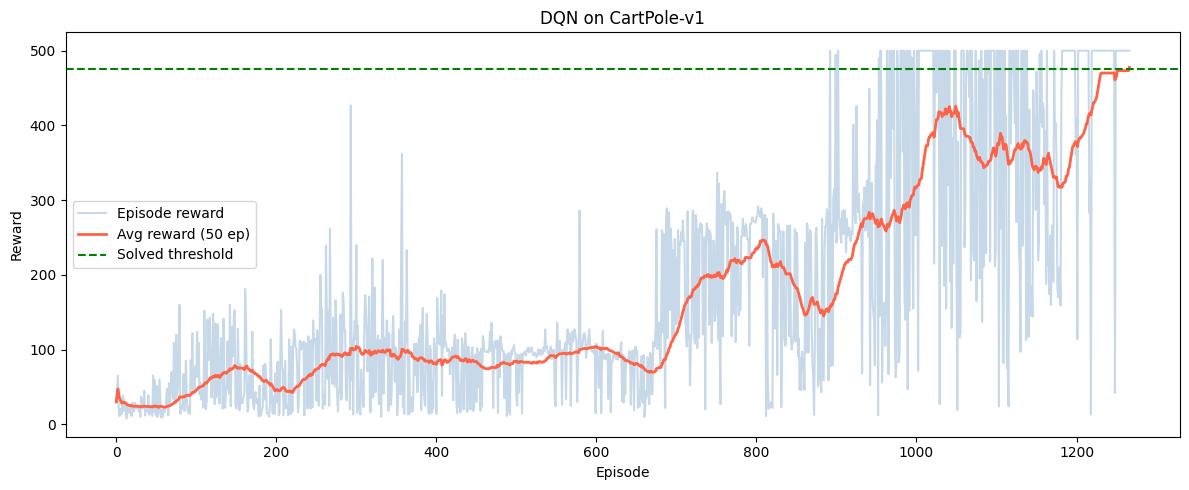

In [ ]:
print("Continuing training...")
print("="*55)

for episode in range(1000, 2000):
    state, info  = env.reset()
    total_reward = 0
    
    while True:
        action = select_action(state, epsilon)
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        
        replay_buffer.push(state, action, reward, next_state, done)
        train_step()
        
        state         = next_state
        total_reward += reward
        
        if done:
            break
    
    epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)
    
    if episode % TARGET_UPDATE == 0:
        target_net.load_state_dict(policy_net.state_dict())
    
    episode_rewards.append(total_reward)
    avg_reward = np.mean(episode_rewards[-50:])
    avg_rewards.append(avg_reward)
    
    if (episode + 1) % 50 == 0:
        print(f"Episode {episode+1:4d}/1000 | "
              f"Avg Reward (last 50): {avg_reward:.1f} | "
              f"Epsilon: {epsilon:.3f}")
    
    if avg_reward >= 475:
        print(f"\nSolved at episode {episode+1}!")
        break

plt.figure(figsize=(12, 5))
plt.plot(episode_rewards, alpha=0.3, color='steelblue', label='Episode reward')
plt.plot(avg_rewards, color='tomato', linewidth=2, label='Avg reward (50 ep)')
plt.axhline(y=475, color='green', linestyle='--', label='Solved threshold')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('DQN on CartPole-v1')
plt.legend()
plt.tight_layout()
plt.show()